In [1]:
import os
import math
import time
import operator
import datetime
import h5py
from tqdm import tqdm
import wandb

import numpy as np
from scipy.ndimage import rotate
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.modules.utils import _pair, _quadruple
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import torchvision

import sys
sys.path.append('/scratch/yichen/notebooks/helper_functions/')
from visualization_functions import show_images

def list_to_dict(lst):
    dictionary = {}
    for index, item in enumerate(lst):
        dictionary[index] = item
    return dictionary

def viz_dataloader(dl, n=8, hist=True, label_converter=None):
    batch = next(iter(dl))
    if len(batch[0]) < n: 
        raise ValueError("n is smaller than batch size, increase n")
    inputs = batch[0][:n]
    labels = list(batch[1][:n].numpy())
    if label_converter:
        for i in range(len(labels)):
            labels[i] = label_converter[labels[i]]
    show_images(torch.permute(inputs, [0,2,3,1]).cpu().numpy(), labels=labels, hist_bins=100)            

class hdf5_dataset(Dataset):
    
    def __init__(self, file_path, folder='train', transform=None, classes=[]):
        self.file_path = file_path
        self.folder = folder
        self.transform = transform
        self.hf = None

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            self.len = len(f[self.folder]['labels'])
        return self.len
    
    def __getitem__(self, idx):
        if self.hf is None:
            self.hf = h5py.File(self.file_path, 'r')
            
        image = np.array(self.hf[self.folder]['data'][idx])
        labels = np.array(self.hf[self.folder]['labels'][idx])
        
        if self.transform:
            image = self.transform(image)
        return image, labels

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

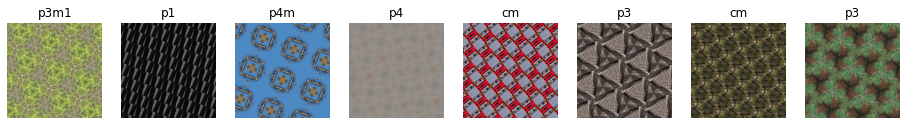

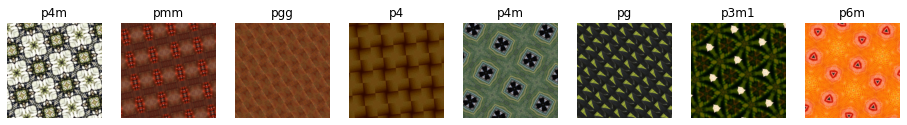

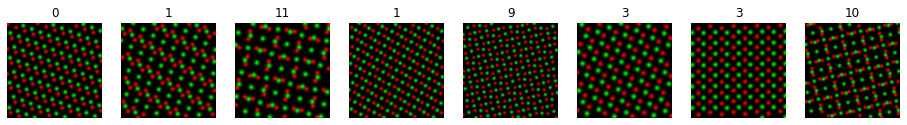

CPU times: user 29.8 s, sys: 1.51 s, total: 31.3 s
Wall time: 9.68 s


In [2]:
%%time
# imagenet
# train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
# train_dl = DataLoader(train_ds, batch_size=300, shuffle=True, num_workers=2)
# viz_dataloader(train_dl, label_converter=label_converter)

train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=300, shuffle=True, num_workers=2)
viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_2m_valid_unchunked.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=300, shuffle=True, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter)

test_ds = hdf5_dataset('/scratch/yichen/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=1024, shuffle=True, num_workers=4)
viz_dataloader(test_dl)

In [3]:
def train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                 epochs, start=0, scheduler=None, 
                 model_name=None, model_dir=None, tracking=False):

    # make directory for the model
    if model_dir and not os.path.isdir(model_dir): os.mkdir(model_dir)

    history = []
    
    if tracking:   
        wandb.watch(model, log_freq=100)
        
    for epoch_idx in range(start, epochs+start):
                
        print("Epoch: {}/{}".format(epoch_idx+1, epochs+start))
        
        avg_train_loss, avg_train_acc = train(model, loss_func, optimizer, device, train_dl, 
                              scheduler=scheduler, tracking=tracking)
        
        avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, valid_dl, 
                              tracking=tracking)
        
        history.append([avg_train_loss, avg_valid_loss])
        
        if test_dl:
            avg_test_loss, avg_test_acc = valid(model, loss_func, device, test_dl, tracking=tracking)
            history.append(avg_test_loss)
            
        if tracking:   
            # record the epoch loss and accuracy:            
            if test_dl:
                wandb.log({'epoch':epoch_idx, 
                           "train_loss": avg_train_loss, 
                           "valid_loss": avg_valid_loss,
                           "train_acc": avg_train_acc, 
                           "valid_acc": avg_valid_acc,
                           "test_loss": avg_test_loss,
                           "test_acc": avg_test_acc})
            else:
                wandb.log({"epoch": epoch_idx,
                           "train_loss": avg_train_loss, 
                           "valid_loss": avg_valid_loss,
                           "train_acc": avg_train_acc, 
                           "valid_acc": avg_valid_acc}) 
                
        if model_name != None:
            torch.save(model, os.path.join(model_dir, model_name+'-epoch-{}.pt'.format(epoch_idx+1)))
                
    return history


def train(model, loss_func, optimizer, device, train_dl, scheduler=None, tracking=False):

    train_data_size = len(train_dl.dataset)
    start_time = time.time()

    # Set to training mode
    model.train()

    # Loss and Accuracy within the epoch
    train_loss = 0.0
    train_acc = 0.0

    for i, batch in enumerate(tqdm(train_dl)):
        inputs = batch[0].to(device).float()
        labels = batch[1].to(device).long()
        model = model.to(device)

        # Clean existing gradients
        optimizer.zero_grad()

        # Forward pass - compute outputs on input data using the model
        outputs = model(inputs)

        # Compute loss
        loss = loss_func(outputs, labels) 

        # Compute the total loss for the batch and add it to train_loss
        train_loss += loss.item() * inputs.size(0)
        
        # Compute the accuracy
        ret, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))

        # Convert correct_counts to float and then compute the mean
        acc = torch.mean(correct_counts.type(torch.FloatTensor))

        # Compute total accuracy in the whole batch and add to train_acc
        train_acc += acc.item() * inputs.size(0)
            
        # Backpropagate the gradients
        loss.backward()

        # Update the parameters
        optimizer.step()
        if scheduler:
            scheduler.step()

    # Find average training loss and training accuracy
    avg_train_loss = train_loss/train_data_size 
    avg_train_acc = train_acc/float(train_data_size)
    print("Training: Loss: {:.4f}, Accuracy: {:.4f}%, Time: {:.4f}mins".format(avg_train_loss, avg_train_acc*100, (time.time()-start_time)/60))

    return avg_train_loss, avg_train_acc


def valid(model, loss_func, device, valid_dl, tracking=False):

    valid_data_size = len(valid_dl.dataset)

    # Loss and Accuracy within the epoch
    valid_loss = 0.0
    valid_acc = 0.0
    
    start_time = time.time()
        
    # Validation - No gradient tracking needed
    with torch.no_grad():

        # Set to evaluation mode
        model.eval()

        # Validation loop
        
        for j, batch in enumerate(tqdm(valid_dl)):
            
            inputs = batch[0].float().to(device)
            labels = batch[1].long().to(device)

            model = model.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)
            
            # Compute loss
            loss = loss_func(outputs, labels) 
            
            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)
            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)     
            
    # Find average training loss and training accuracy
    avg_valid_loss = valid_loss/valid_data_size 
    avg_valid_acc = valid_acc/float(valid_data_size)
    print("Validation : Loss : {:.4f}, Accuracy: {:.4f}%, Time: {:.2f}mins".format(avg_valid_loss, avg_valid_acc*100, (time.time()-start_time)/60))

    return avg_valid_loss, avg_valid_acc

In [4]:
model = models.resnet50()

model.fc = nn.Sequential(nn.BatchNorm1d(2048),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 2048, out_features=512, bias=False),
                         nn.ReLU(inplace=True),

                         nn.BatchNorm1d(512),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 512, out_features=64, bias=False),
                         nn.ReLU(inplace=True),
                         
                         nn.BatchNorm1d(64),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=64, out_features=17, bias=True)
                        )

In [5]:
model(torch.randn(2,3,256,256)).shape

torch.Size([2, 17])

# train

In [6]:
config = {
    'device': torch.device('cuda:3'),
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = '05312023-benchmark-resnet50_from_scratch-v4_10m-test'

wandb.init(project='symmetry_paper', entity='yig319', 
           name=NAME, config=config, id=NAME)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [7]:
device = config['device']
lr = 1e-3
start = 0
epochs = 1

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Ada
m(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models/', tracking=False)

Epoch: 1/1


100%|██████████| 6667/6667 [1:00:55<00:00,  1.82it/s]


Training: Loss: 0.8006, Accuracy: 72.5586%, Time: 3655.8707s


100%|██████████| 6667/6667 [26:26<00:00,  4.20it/s]


Validation : Loss : 0.1270, Accuracy: 95.3685%, Time: 1586.9742s


 39%|███▊      | 766/1985 [11:08<17:43,  1.15it/s]


KeyboardInterrupt: 

In [7]:
valid(model, loss_func, torch.device('cuda:2'), test_dl, tracking=False)

NameError: name 'loss_func' is not defined